# Experiment 1- Vae
Dataset- Cifar 10

ref- pytorch docs and some medium articles i found on google


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
# folder to save stuff
save_path = '/content/drive/MyDrive/VAE_results'
os.makedirs(save_path, exist_ok=True)

In [4]:
# using gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('using:', device)

using: cuda


In [5]:
#load dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)


100%|██████████| 170M/170M [00:04<00:00, 38.1MB/s]


In [7]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # encoder part
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )

        # mu and log_var for latent spacee
        self.fc_mu = nn.Linear(128*4*4, latent_dim)
        self.fc_logvar = nn.Linear(128*4*4, latent_dim)

        # decoder part
        self.fc_decode = nn.Linear(latent_dim, 128*4*4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    #reparemeter trick
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [8]:
#loss function
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss, recon_loss, kl_loss

In [11]:
#training
model = VAE(latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
recon_losses = []
kl_losses = []

for epoch in range(num_epochs):
    model.train()
    total_recon = 0
    total_kl = 0

    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(imgs)
        loss, recon_l, kl_l = vae_loss(recon, imgs, mu, logvar)

        loss.backward()
        optimizer.step()

        total_recon += recon_l.item()
        total_kl += kl_l.item()

    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f'Epoch {epoch+1}/{num_epochs}, recon: {avg_recon:.3f}, kl: {avg_kl:.3f}')


# save model
torch.save(model.state_dict(), os.path.join(save_path, 'vae_model.pth'))
print('model saved')

Epoch 1/50, recon: 1908.743, kl: 24.424
Epoch 2/50, recon: 1815.565, kl: 32.840
Epoch 3/50, recon: 1799.204, kl: 35.675
Epoch 4/50, recon: 1792.411, kl: 37.489
Epoch 5/50, recon: 1788.018, kl: 38.929
Epoch 6/50, recon: 1784.483, kl: 40.067
Epoch 7/50, recon: 1782.691, kl: 40.768
Epoch 8/50, recon: 1781.040, kl: 41.238
Epoch 9/50, recon: 1779.796, kl: 41.728
Epoch 10/50, recon: 1778.522, kl: 42.210
Epoch 11/50, recon: 1777.659, kl: 42.579
Epoch 12/50, recon: 1776.641, kl: 42.938
Epoch 13/50, recon: 1775.951, kl: 43.184
Epoch 14/50, recon: 1775.520, kl: 43.405
Epoch 15/50, recon: 1774.974, kl: 43.597
Epoch 16/50, recon: 1774.642, kl: 43.717
Epoch 17/50, recon: 1774.241, kl: 43.839
Epoch 18/50, recon: 1773.779, kl: 43.929
Epoch 19/50, recon: 1773.681, kl: 44.006
Epoch 20/50, recon: 1773.239, kl: 44.161
Epoch 21/50, recon: 1772.917, kl: 44.278
Epoch 22/50, recon: 1772.770, kl: 44.355
Epoch 23/50, recon: 1772.401, kl: 44.519
Epoch 24/50, recon: 1772.198, kl: 44.588
Epoch 25/50, recon: 1772.

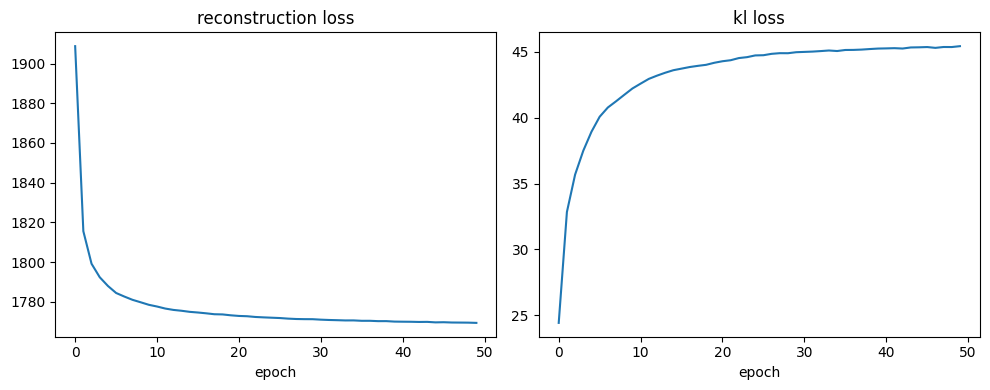

In [12]:
#training curve
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(recon_losses)
plt.title('reconstruction loss')
plt.xlabel('epoch')

plt.subplot(1,2,2)
plt.plot(kl_losses)
plt.title('kl loss')
plt.xlabel('epoch')

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'training_curves.png'))
plt.show()

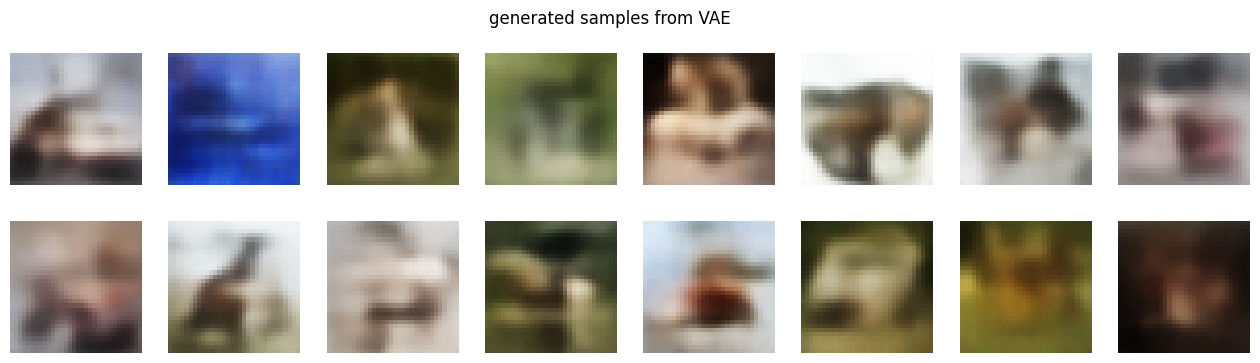

In [13]:
#new generated img
model.eval()
with torch.no_grad():
    z = torch.randn(16, 128).to(device)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = samples[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('generated samples from VAE')
plt.savefig(os.path.join(save_path, 'generated_samples.png'))
plt.show()

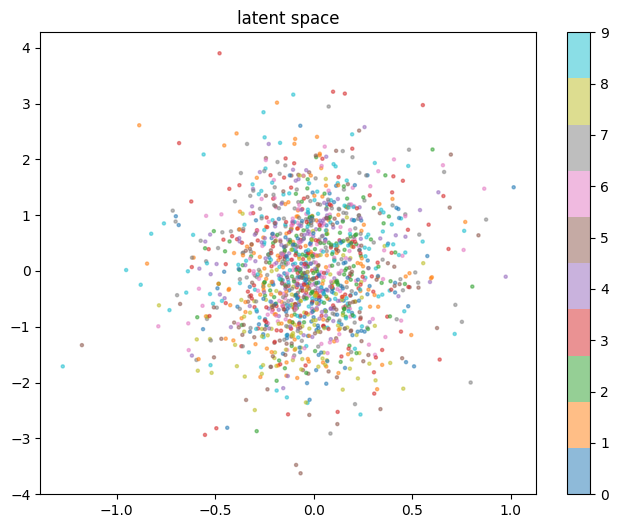

In [15]:
model.eval()
all_mu = []
all_labels = []

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        mu, _ = model.encode(imgs)
        all_mu.append(mu.cpu())
        all_labels.append(labels)
        if len(all_mu) > 10:  # only do first few batches
            break

all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

plt.figure(figsize=(8,6))
scatter = plt.scatter(all_mu[:,0], all_mu[:,1], c=all_labels, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter)
plt.title('latent space')
plt.savefig(os.path.join(save_path, 'latent_space.png'))
plt.show()

